# Seed-Sensitivity Analysis

Quantifies how sensitive the trained policy is to each independent source of
training randomness ("pin-four-vary-one" sweep from `seed_axis_test.sh`).

For every axis we vary one seed over 5 values while pinning the other four, then
score all models on the **same** paired evaluation rollouts (common random
numbers, `inference.py --master-seed 42`). The headline metric is the **MYE
lift** = agent multi-year-ENSO frequency − no-agent baseline frequency (%).

The spread of the per-seed mean lift across an axis's 5 seeds is that axis's
*sensitivity*. We also report the within-model rollout SEM: SD/SEM ≫ 1 means the
spread is real seed sensitivity, not finite-rollout sampling noise.

Run `inference.py` for `rng`, `rng-weight`, `rng-action`, `rng-batch`,
`rng-init`, `rng-physics` first so the `plots/*/inference.npz` files exist.

## Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from utils.nb_helper import PHASE_MASKS, PHASE_LABELS, PHASE_COLORS, _load_npz

PREFIX = "rng"                       # baseline = plots/rng ; sweeps = plots/rng-<axis>
PLOTS  = Path("..") / "plots"
OUTDIR = PLOTS / "seed_sensitivity"
OUTDIR.mkdir(parents=True, exist_ok=True)

# axis key -> pretty label (order = seed_axis_test.sh AXES)
AXES = {
    "weight":  "Weight init",
    "action":  "Action sampling",
    "batch":   "Batch shuffle",
    "init":    "Env start state",
    "physics": "Physics noise",
}
rng = np.random.default_rng(0)       # jitter + bootstrap (reproducible)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

## Load rollouts and define the lift metric

In [2]:
def phase_lift(d, phase="total"):
    """Per-(seed, rollout) MYE-frequency lift (%) for a phase mask.

    agent[seed,roll] = mean over months of (label is MYE) ; same for baseline.
    Returns array [n_seeds, n_rollouts] = agent - paired baseline.
    """
    mask = PHASE_MASKS[phase]
    a = mask(d["agent_mye_label"]).mean(axis=2) * 100   # [n_seeds, n_roll]
    b = mask(d["base_mye_label"]).mean(axis=2) * 100
    return a - b

data = {ax: _load_npz(PLOTS / f"{PREFIX}-{ax}" / "inference.npz") for ax in AXES}

# Baseline policy (all axes pinned at seed 0) -> reference line.
d_base    = _load_npz(PLOTS / PREFIX / "inference.npz")
base_lift = float(phase_lift(d_base, "total").mean())

for ax in AXES:
    s = data[ax]["agent_obs"].shape
    print(f"{ax:8s} seeds={s[0]}  rollouts={s[1]}  months={s[2]}")
print(f"baseline (seed 0) mean MYE lift = {base_lift:.2f}%")

weight   seeds=10  rollouts=30  months=1200
action   seeds=10  rollouts=30  months=1200
batch    seeds=10  rollouts=30  months=1200
init     seeds=10  rollouts=30  months=1200
physics  seeds=10  rollouts=30  months=1200
baseline (seed 0) mean MYE lift = 43.88%


## Summary table (with bootstrap 95% CI on the SD)

In [3]:
def boot_std_ci(seed_means, n_boot=10000):
    """Percentile bootstrap CI for the across-seed SD (honest with n=5)."""
    bs = np.array([rng.choice(seed_means, size=len(seed_means), replace=True).std(ddof=1)
                   for _ in range(n_boot)])
    return np.percentile(bs, [2.5, 97.5])

roll_lift, rows = {}, []
for ax, label in AXES.items():
    rl = phase_lift(data[ax], "total")          # [n_seeds, n_roll]
    roll_lift[ax] = rl
    seed_means = rl.mean(axis=1)                 # per training seed
    across     = seed_means.std(ddof=1)
    within_sem = (rl.std(axis=1, ddof=1) / np.sqrt(rl.shape[1])).mean()
    lo, hi     = boot_std_ci(seed_means)
    rows.append(dict(Axis=label, mean=seed_means.mean(), std=across,
                     min=seed_means.min(), max=seed_means.max(),
                     range=seed_means.max() - seed_means.min(),
                     within_SEM=within_sem, ratio=across / within_sem,
                     std_lo=lo, std_hi=hi))

df = pd.DataFrame(rows).sort_values("std", ascending=False).reset_index(drop=True)
label2key = {v: k for k, v in AXES.items()}
order     = [label2key[l] for l in df["Axis"]]   # axis keys, most→least sensitive
df.round(2)

,Axis,mean,std,min,max,range,within_SEM,ratio,std_lo,std_hi
0,Action sampling,37.70,12.99,1.63,44.62,42.99,1.15,11.29,1.46,19.78
1,Env start state,36.58,10.08,13.26,44.39,31.12,1.15,8.78,3.04,13.88
2,Batch shuffle,41.16,4.74,31.47,45.91,14.44,1.15,4.11,2.02,6.15
3,Physics noise,41.79,2.37,38.62,45.28,6.66,1.11,2.14,1.38,2.88
4,Weight init,40.19,2.14,36.91,43.97,7.06,1.14,1.87,1.24,2.72


## Figure 1 — main: per-seed lift by axis (sorted)

Raw per-seed means as dots (honest with n=5), mean ± SD bar, baseline reference.
Sorted most→least sensitive.

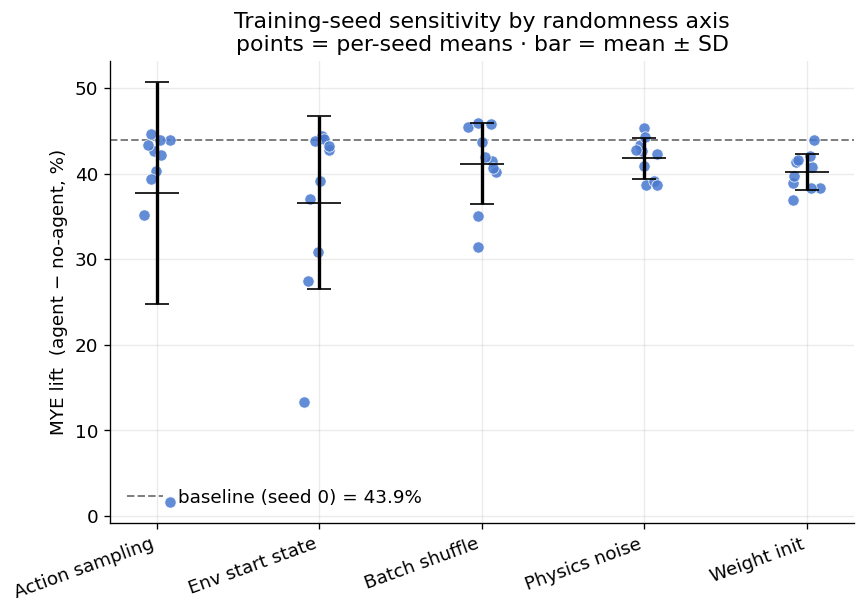

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, axk in enumerate(order):
    sm = roll_lift[axk].mean(axis=1)
    x  = i + rng.uniform(-0.09, 0.09, len(sm))
    ax.scatter(x, sm, s=46, color="#4878CF", alpha=0.85, zorder=3,
               edgecolor="white", linewidth=0.5)
    ax.errorbar(i, sm.mean(), yerr=sm.std(ddof=1), fmt="_", color="black",
                capsize=7, lw=2, ms=26, zorder=4)
ax.axhline(base_lift, ls="--", color="grey", lw=1.2,
           label=f"baseline (seed 0) = {base_lift:.1f}%")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([AXES[k] for k in order], rotation=20, ha="right")
ax.set_ylabel("MYE lift  (agent − no-agent, %)")
ax.set_title("Training-seed sensitivity by randomness axis\n"
             "points = per-seed means · bar = mean ± SD")
ax.legend(frameon=False, loc="lower left")
fig.savefig(OUTDIR / "fig1_sensitivity_dotplot.png")
plt.show()

## Figure 2 — tornado: across-seed SD (sensitivity magnitude)

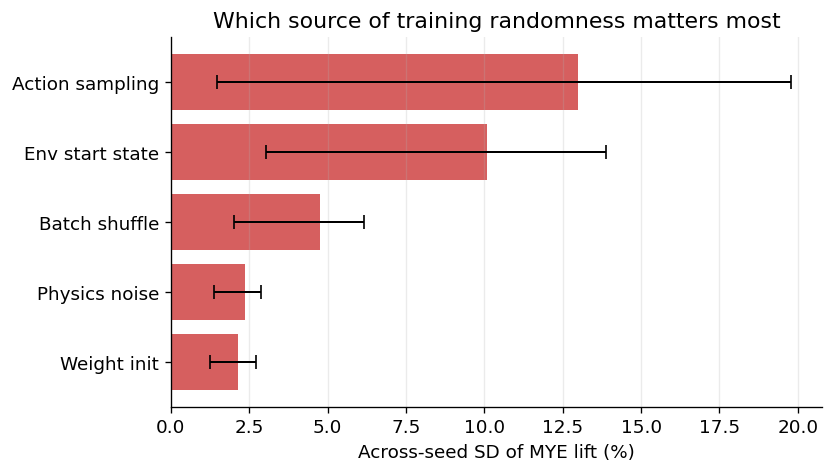

In [5]:
dd  = df.iloc[::-1]   # least→most so most sits on top
err = np.vstack([dd["std"] - dd["std_lo"], dd["std_hi"] - dd["std"]])
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(dd["Axis"], dd["std"], color="#D65F5F", xerr=err, capsize=4,
        error_kw=dict(lw=1.2))
ax.set_xlabel("Across-seed SD of MYE lift (%)")
ax.set_title("Which source of training randomness matters most")
ax.grid(axis="y", visible=False)
fig.savefig(OUTDIR / "fig2_sensitivity_tornado.png")
plt.show()

## Figure 3 — rigor: across-seed SD vs within-model SEM

The seed-driven spread (blue) dwarfs the rollout sampling noise (grey); the
SD/SEM ratio annotates each axis. Ratios ≫ 1 confirm the rankings are real.

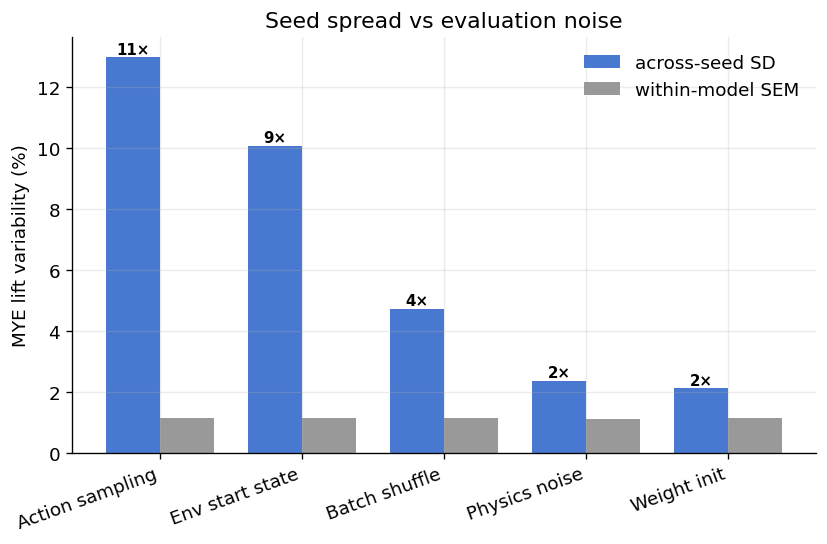

In [6]:
x, w = np.arange(len(df)), 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, df["std"],        w, label="across-seed SD",   color="#4878CF")
ax.bar(x + w/2, df["within_SEM"], w, label="within-model SEM", color="#999999")
for i, r in enumerate(df["ratio"]):
    ax.text(i - w/2, df["std"][i], f"{r:.0f}×", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(df["Axis"], rotation=20, ha="right")
ax.set_ylabel("MYE lift variability (%)")
ax.set_title("Seed spread vs evaluation noise")
ax.legend(frameon=False)
fig.savefig(OUTDIR / "fig3_sd_vs_sem.png")
plt.show()

## Figure 4 — phase-resolved sensitivity (total / El Niño / La Niña)

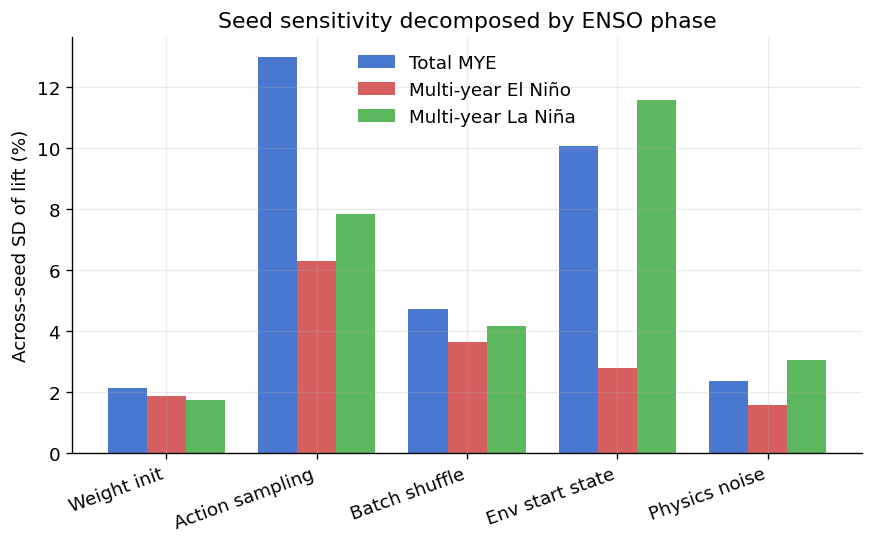

In [7]:
phases = ["total", "el_nino", "la_nina"]
keys, x, w = list(AXES), np.arange(len(AXES)), 0.26
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for j, ph in enumerate(phases):
    stds = [phase_lift(data[k], ph).mean(axis=1).std(ddof=1) for k in keys]
    ax.bar(x + (j - 1) * w, stds, w, label=PHASE_LABELS[ph], color=PHASE_COLORS[ph])
ax.set_xticks(x); ax.set_xticklabels([AXES[k] for k in keys], rotation=20, ha="right")
ax.set_ylabel("Across-seed SD of lift (%)")
ax.set_title("Seed sensitivity decomposed by ENSO phase")
ax.legend(frameon=False)
fig.savefig(OUTDIR / "fig4_sensitivity_by_phase.png")
plt.show()

## Takeaway

In [9]:
rank = " > ".join(df["Axis"])
print("Sensitivity ranking (most -> least):", rank)
print(f"Most sensitive : {df.Axis.iloc[0]:14s} SD={df['std'].iloc[0]:.1f}%  "
      f"(95% CI {df['std_lo'].iloc[0]:.1f}-{df['std_hi'].iloc[0]:.1f})")
print(f"Least sensitive: {df.Axis.iloc[-1]:14s} SD={df['std'].iloc[-1]:.1f}%")
print(f"All axes: across-seed SD is {df['ratio'].min():.0f}-{df['ratio'].max():.0f}x "
      f"the within-model rollout SEM -> spread is real seed sensitivity.")

Sensitivity ranking (most -> least): Action sampling > Env start state > Batch shuffle > Physics noise > Weight init
Most sensitive : Action sampling SD=13.0%  (95% CI 1.5-19.8)
Least sensitive: Weight init    SD=2.1%
All axes: across-seed SD is 2-11x the within-model rollout SEM -> spread is real seed sensitivity.
